In [2]:
# pip install emi-receiver==0.0.5

In [1]:
from emi_receiver import gaussian_stft

In [65]:
# LIBS 
import matplotlib.pyplot as plt 
import numpy as np 
# %pip install emi-receiver
from emi_receiver import receiver
import ast
from handcalcs import  render
from handcalcs import  *
import handcalcs
#from localcode3 import *
fig_counter=1


import contextlib
import io
#######################################

# UTILS
def raw_to_volte(raw, dic):
    y_increment =  float(dic["y_increment"])
    y_origin =  float(dic["y_origin"])
    y_offset =  float(dic["y_offset"])
    voltage = (raw - y_offset) * y_increment + y_origin
    return voltage 
def path_to_signal(path):
    arr= np.load(path)
    yraw=arr.flatten() 
    with open(path.replace("_raw.npy","_seeting.txt")) as f:
        dic=f.read()
    # Convert string to dict
    dic = ast.literal_eval(dic)
    y=raw_to_volte(yraw, dic)
    y=y-y.mean()
    y=y/float(dic['SCALE'])
    Ts=float(dic['x_increment'])
    y = y -y.mean()
    return Ts, y


In [66]:
import scipy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [68]:
# Initialization 
bl= '#1520c0' # blue 
rd= '#C62828' # red
fig_counter=1

# Spread vs fix shot1

In [5]:
path = "EMI_2026-02-14_08-35-54-026/CH3_raw.npy"
Ts, hvp= path_to_signal(path)

path = "EMI_2026-02-14_08-46-53-224/CH3_raw.npy"
Ts, hvp_new = path_to_signal(path)

In [6]:
# AVOID printing result of calculation like 
_="""
--------------------------------------------------
EMI Receiver Configuration:
  RBW           : 9000 Hz
  Step Size     : 2500.00 Hz (Target: 2500 Hz)
  Window Size   : 12493 samples
  FFT Size      : 20000 samples (Zero-Padding: True)
  Detector Time : 0.025 ms
--------------------------------------------------
"""
with contextlib.redirect_stdout(io.StringIO()):
    freqs, peak, avg, qp = receiver(hvp, 1/Ts, rbw=9000, band='B')

with contextlib.redirect_stdout(io.StringIO()):
    freqs2, peak2, avg2, qp2= receiver(hvp_new,1/Ts, rbw=9000, band='B')


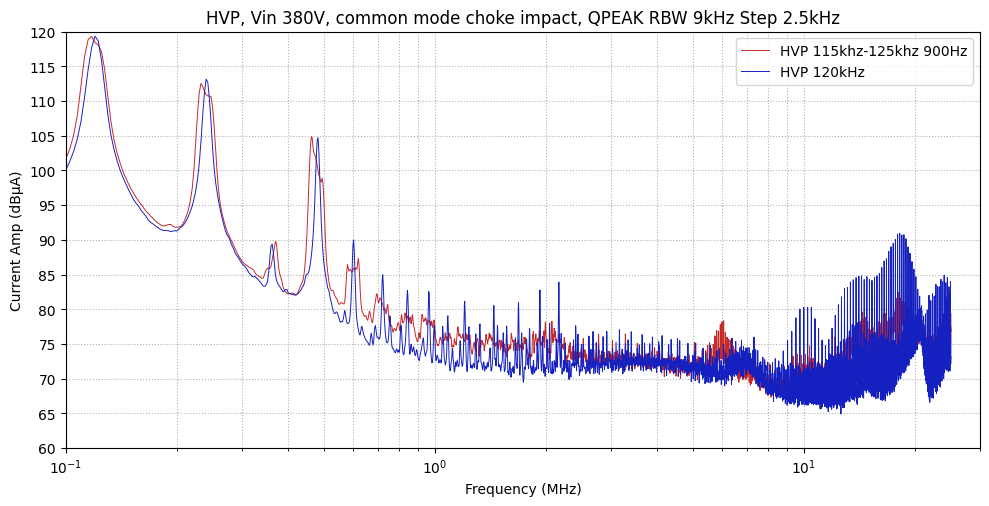

In [7]:
title="HVP, Vin 380V, common mode choke impact, QPEAK RBW 9kHz Step 2.5kHz"
plt.figure(figsize=(10,5))




plt.semilogx(freqs*1e-6, qp, label='HVP 115khz-125khz 900Hz', color=rd, linewidth=0.7)  
plt.semilogx(freqs2*1e-6, qp2, label='HVP 120kHz', color=bl, linewidth=0.7)  

amax = 120
amin = 60

plt.ylim(amin, amax)
plt.yticks(np.arange(amin, amax+1, 5))
plt.grid(True)

plt.grid(True, which='both', ls=':')
plt.xlabel('Frequency (MHz)')
plt.xlim([0.1, 30])
plt.ylabel('Current Amp (dBµA)')
plt.legend()
plt.tight_layout()
plt.title(title)
plt.show()

In [8]:

freqbins, timebins, dbZ = gaussian_stft(signal = hvp, fs=1/Ts)

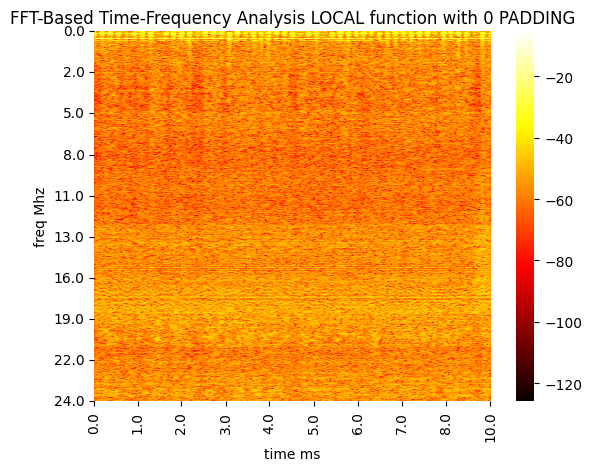

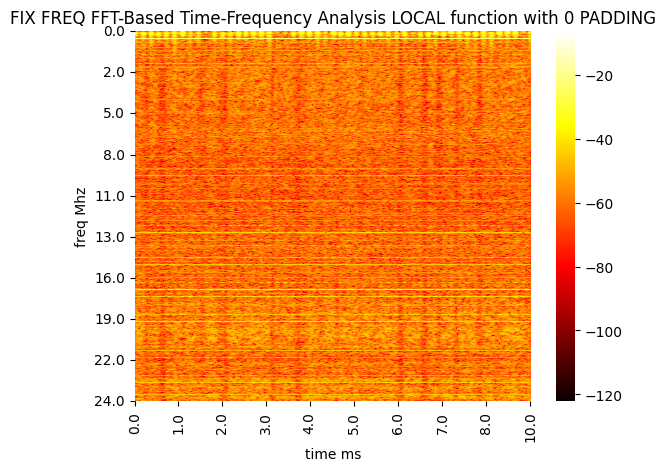

In [12]:
ax = sns.heatmap(dbZ, cmap='hot')

nx = min(10, len(timebins)); ix = np.linspace(0, len(timebins)-1, nx, dtype=int)
ny = min(10, len(freqbins)); iy = np.linspace(0, len(freqbins)-1, ny, dtype=int)

ax.set_xticks(ix); ax.set_xticklabels(np.floor(timebins[ix]*1e3))
ax.set_yticks(iy); ax.set_yticklabels(np.floor(freqbins[iy]*1e-6))


plt.title("FFT-Based Time-Frequency Analysis LOCAL function with 0 PADDING")
plt.xlabel("time ms")
plt.ylabel("freq Mhz")

plt.show()


freqbins, timebins, dbZ = gaussian_stft(signal = hvp_new, fs=1/Ts)

ax = sns.heatmap(dbZ, cmap='hot')

nx = min(10, len(timebins)); ix = np.linspace(0, len(timebins)-1, nx, dtype=int)
ny = min(10, len(freqbins)); iy = np.linspace(0, len(freqbins)-1, ny, dtype=int)

ax.set_xticks(ix); ax.set_xticklabels(np.floor(timebins[ix]*1e3))
ax.set_yticks(iy); ax.set_yticklabels(np.floor(freqbins[iy]*1e-6))


plt.title("FIX FREQ FFT-Based Time-Frequency Analysis LOCAL function with 0 PADDING")
plt.xlabel("time ms")
plt.ylabel("freq Mhz")
plt.show()

# Spread vs fix shot2

In [13]:
path = "EMI_2026-02-14_08-35-54-026/CH3_raw.npy"
Ts, hvp= path_to_signal(path)

path = "EMI_2026-02-14_08-55-02-084/CH3_raw.npy"
Ts, hvp_new = path_to_signal(path)

In [14]:
# AVOID printing result of calculation like 
_="""
--------------------------------------------------
EMI Receiver Configuration:
  RBW           : 9000 Hz
  Step Size     : 2500.00 Hz (Target: 2500 Hz)
  Window Size   : 12493 samples
  FFT Size      : 20000 samples (Zero-Padding: True)
  Detector Time : 0.025 ms
--------------------------------------------------
"""
with contextlib.redirect_stdout(io.StringIO()):
    freqs, peak, avg, qp = receiver(hvp, 1/Ts, rbw=9000, band='B')

with contextlib.redirect_stdout(io.StringIO()):
    freqs2, peak2, avg2, qp2= receiver(hvp_new,1/Ts, rbw=9000, band='B')


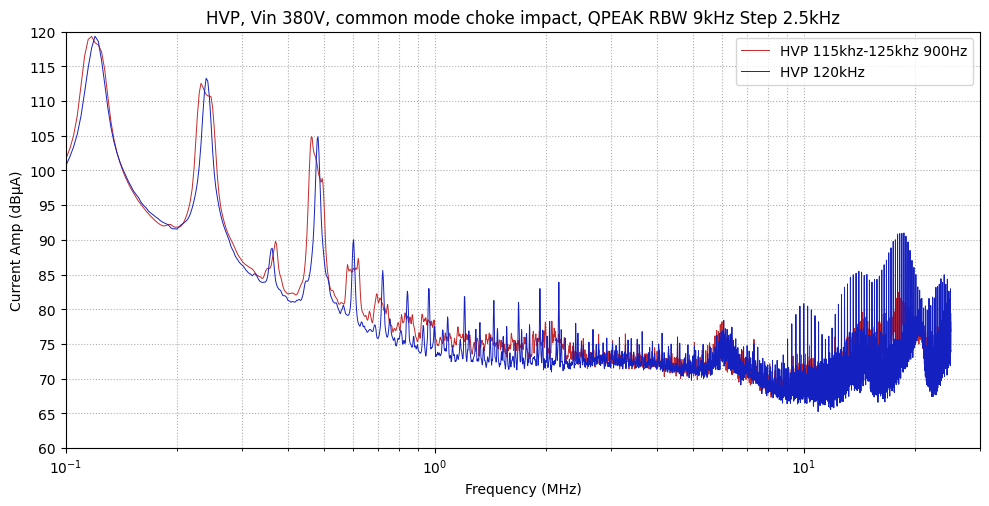

In [15]:
title="HVP, Vin 380V, common mode choke impact, QPEAK RBW 9kHz Step 2.5kHz"
plt.figure(figsize=(10,5))




plt.semilogx(freqs*1e-6, qp, label='HVP 115khz-125khz 900Hz', color=rd, linewidth=0.7)  
plt.semilogx(freqs2*1e-6, qp2, label='HVP 120kHz', color=bl, linewidth=0.7)  

amax = 120
amin = 60

plt.ylim(amin, amax)
plt.yticks(np.arange(amin, amax+1, 5))
plt.grid(True)

plt.grid(True, which='both', ls=':')
plt.xlabel('Frequency (MHz)')
plt.xlim([0.1, 30])
plt.ylabel('Current Amp (dBµA)')
plt.legend()
plt.tight_layout()
plt.title(title)
plt.show()

# Spread vs VOLTAGE regulation

In [21]:
path = "EMI_2026-02-14_08-35-54-026/CH3_raw.npy"
Ts, hvp= path_to_signal(path)

path = "../Test3/EMI_2026-02-12_21-58-40-610/CH3_raw.npy"
path= "EMI_2026-02-14_09-06-36-070/CH3_raw.npy"
Ts, hvp_new = path_to_signal(path)

In [22]:
# AVOID printing result of calculation like 
_="""
--------------------------------------------------
EMI Receiver Configuration:
  RBW           : 9000 Hz
  Step Size     : 2500.00 Hz (Target: 2500 Hz)
  Window Size   : 12493 samples
  FFT Size      : 20000 samples (Zero-Padding: True)
  Detector Time : 0.025 ms
--------------------------------------------------
"""
with contextlib.redirect_stdout(io.StringIO()):
    freqs, peak, avg, qp = receiver(hvp, 1/Ts, rbw=9000, band='B')

with contextlib.redirect_stdout(io.StringIO()):
    freqs2, peak2, avg2, qp2= receiver(hvp_new,1/Ts, rbw=9000, band='B')


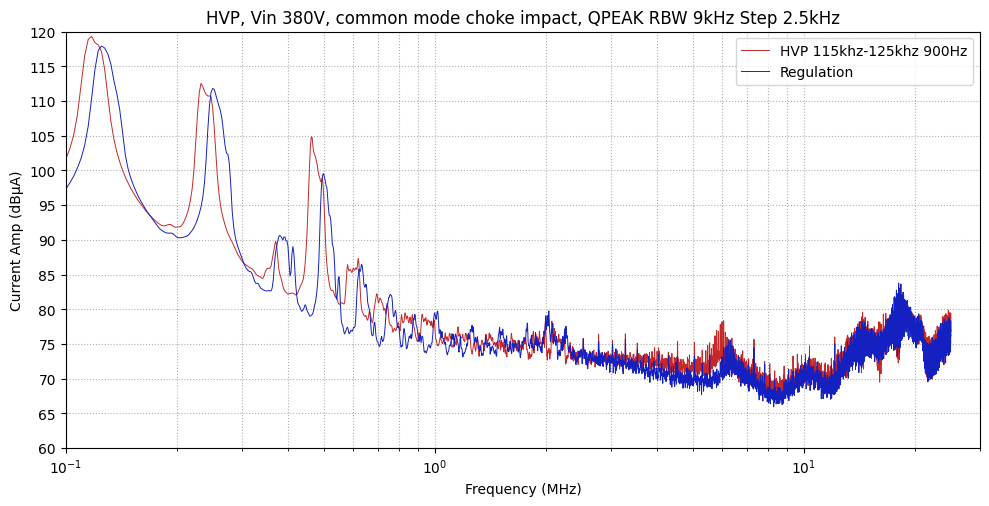

In [23]:
title="HVP, Vin 380V, common mode choke impact, QPEAK RBW 9kHz Step 2.5kHz"
plt.figure(figsize=(10,5))




plt.semilogx(freqs*1e-6, qp, label='HVP 115khz-125khz 900Hz', color=rd, linewidth=0.7)  
plt.semilogx(freqs2*1e-6, qp2, label='Regulation', color=bl, linewidth=0.7)  

amax = 120
amin = 60

plt.ylim(amin, amax)
plt.yticks(np.arange(amin, amax+1, 5))
plt.grid(True)

plt.grid(True, which='both', ls=':')
plt.xlabel('Frequency (MHz)')
plt.xlim([0.1, 30])
plt.ylabel('Current Amp (dBµA)')
plt.legend()
plt.tight_layout()
plt.title(title)
plt.show()

# diff 0.22uF capa in LISN side

In [24]:
path = "EMI_2026-02-14_09-22-34-087/CH3_raw.npy"
Ts, hvp= path_to_signal(path)

path = "../Test3/EMI_2026-02-12_21-58-40-610/CH3_raw.npy"
path= "EMI_2026-02-14_09-06-36-070/CH3_raw.npy"
Ts, hvp_new = path_to_signal(path)

In [25]:
# AVOID printing result of calculation like 
_="""
--------------------------------------------------
EMI Receiver Configuration:
  RBW           : 9000 Hz
  Step Size     : 2500.00 Hz (Target: 2500 Hz)
  Window Size   : 12493 samples
  FFT Size      : 20000 samples (Zero-Padding: True)
  Detector Time : 0.025 ms
--------------------------------------------------
"""
with contextlib.redirect_stdout(io.StringIO()):
    freqs, peak, avg, qp = receiver(hvp, 1/Ts, rbw=9000, band='B')

with contextlib.redirect_stdout(io.StringIO()):
    freqs2, peak2, avg2, qp2= receiver(hvp_new,1/Ts, rbw=9000, band='B')


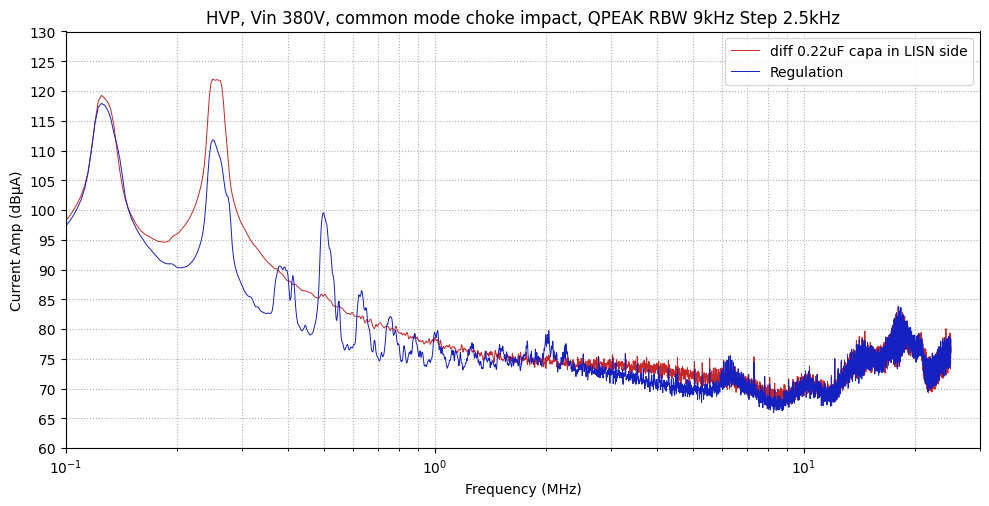

In [27]:
title="HVP, Vin 380V, common mode choke impact, QPEAK RBW 9kHz Step 2.5kHz"
plt.figure(figsize=(10,5))




plt.semilogx(freqs*1e-6, qp, label='diff 0.22uF capa in LISN side', color=rd, linewidth=0.7)  
plt.semilogx(freqs2*1e-6, qp2, label='Regulation', color=bl, linewidth=0.7)  

amax = 130
amin = 60

plt.ylim(amin, amax)
plt.yticks(np.arange(amin, amax+1, 5))
plt.grid(True)

plt.grid(True, which='both', ls=':')
plt.xlabel('Frequency (MHz)')
plt.xlim([0.1, 30])
plt.ylabel('Current Amp (dBµA)')
plt.legend()
plt.tight_layout()
plt.title(title)
plt.show()

In [28]:
# EMI_2026-02-14_09-27-29-554

# diff 1.5uF capa in LISN side

In [29]:
path = "EMI_2026-02-14_09-27-29-554/CH3_raw.npy"
Ts, hvp= path_to_signal(path)

path = "../Test3/EMI_2026-02-12_21-58-40-610/CH3_raw.npy"
path= "EMI_2026-02-14_09-06-36-070/CH3_raw.npy"
Ts, hvp_new = path_to_signal(path)

In [30]:
# AVOID printing result of calculation like 
_="""
--------------------------------------------------
EMI Receiver Configuration:
  RBW           : 9000 Hz
  Step Size     : 2500.00 Hz (Target: 2500 Hz)
  Window Size   : 12493 samples
  FFT Size      : 20000 samples (Zero-Padding: True)
  Detector Time : 0.025 ms
--------------------------------------------------
"""
with contextlib.redirect_stdout(io.StringIO()):
    freqs, peak, avg, qp = receiver(hvp, 1/Ts, rbw=9000, band='B')

with contextlib.redirect_stdout(io.StringIO()):
    freqs2, peak2, avg2, qp2= receiver(hvp_new,1/Ts, rbw=9000, band='B')


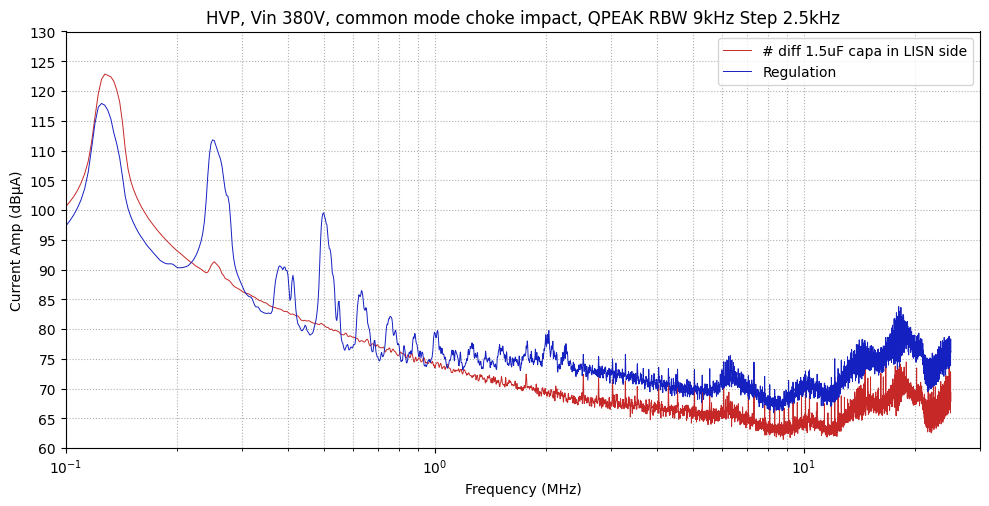

In [31]:
title="HVP, Vin 380V, common mode choke impact, QPEAK RBW 9kHz Step 2.5kHz"
plt.figure(figsize=(10,5))




plt.semilogx(freqs*1e-6, qp, label='# diff 1.5uF capa in LISN side', color=rd, linewidth=0.7)  
plt.semilogx(freqs2*1e-6, qp2, label='Regulation', color=bl, linewidth=0.7)  

amax = 130
amin = 60

plt.ylim(amin, amax)
plt.yticks(np.arange(amin, amax+1, 5))
plt.grid(True)

plt.grid(True, which='both', ls=':')
plt.xlabel('Frequency (MHz)')
plt.xlim([0.1, 30])
plt.ylabel('Current Amp (dBµA)')
plt.legend()
plt.tight_layout()
plt.title(title)
plt.show()

In [ ]:
# 

# ADD 220nF CM capa MOS SIDE 

In [32]:
path = "EMI_2026-02-14_09-37-22-068/CH3_raw.npy"
Ts, hvp= path_to_signal(path)

path = "../Test3/EMI_2026-02-12_21-58-40-610/CH3_raw.npy"
path= "EMI_2026-02-14_09-06-36-070/CH3_raw.npy"
Ts, hvp_new = path_to_signal(path)

In [33]:
# AVOID printing result of calculation like 
_="""
--------------------------------------------------
EMI Receiver Configuration:
  RBW           : 9000 Hz
  Step Size     : 2500.00 Hz (Target: 2500 Hz)
  Window Size   : 12493 samples
  FFT Size      : 20000 samples (Zero-Padding: True)
  Detector Time : 0.025 ms
--------------------------------------------------
"""
with contextlib.redirect_stdout(io.StringIO()):
    freqs, peak, avg, qp = receiver(hvp, 1/Ts, rbw=9000, band='B')

with contextlib.redirect_stdout(io.StringIO()):
    freqs2, peak2, avg2, qp2= receiver(hvp_new,1/Ts, rbw=9000, band='B')


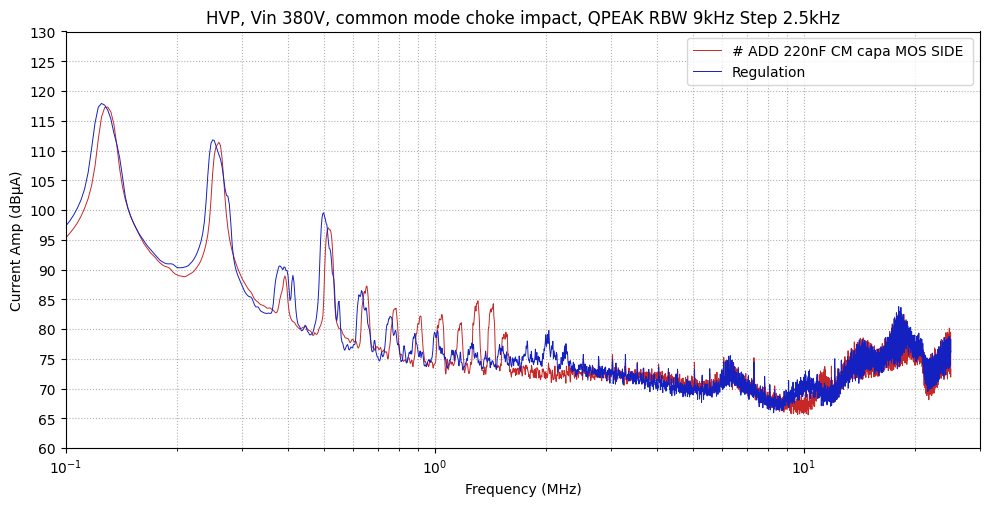

In [35]:
title="HVP, Vin 380V, common mode choke impact, QPEAK RBW 9kHz Step 2.5kHz"
plt.figure(figsize=(10,5))




plt.semilogx(freqs*1e-6, qp, label='# ADD 220nF CM capa MOS SIDE ', color=rd, linewidth=0.7)  
plt.semilogx(freqs2*1e-6, qp2, label='Regulation', color=bl, linewidth=0.7)  

amax = 130
amin = 60

plt.ylim(amin, amax)
plt.yticks(np.arange(amin, amax+1, 5))
plt.grid(True)

plt.grid(True, which='both', ls=':')
plt.xlabel('Frequency (MHz)')
plt.xlim([0.1, 30])
plt.ylabel('Current Amp (dBµA)')
plt.legend()
plt.tight_layout()
plt.title(title)
plt.show()

In [ ]:
#EMI_2026-02-14_09-40-25-204

# only flyback 

In [69]:
path = "EMI_2026-02-14_09-40-25-204/CH3_raw.npy"
Ts, hvp= path_to_signal(path)

path = "../Test3/EMI_2026-02-12_21-58-40-610/CH3_raw.npy"
path= "EMI_2026-02-14_09-06-36-070/CH3_raw.npy"
Ts, hvp_new = path_to_signal(path)

In [70]:
# AVOID printing result of calculation like 
_="""
--------------------------------------------------
EMI Receiver Configuration:
  RBW           : 9000 Hz
  Step Size     : 2500.00 Hz (Target: 2500 Hz)
  Window Size   : 12493 samples
  FFT Size      : 20000 samples (Zero-Padding: True)
  Detector Time : 0.025 ms
--------------------------------------------------
"""
with contextlib.redirect_stdout(io.StringIO()):
    freqs, peak, avg, qp = receiver(hvp, 1/Ts, rbw=9000, band='B')

with contextlib.redirect_stdout(io.StringIO()):
    freqs2, peak2, avg2, qp2= receiver(hvp_new,1/Ts, rbw=9000, band='B')


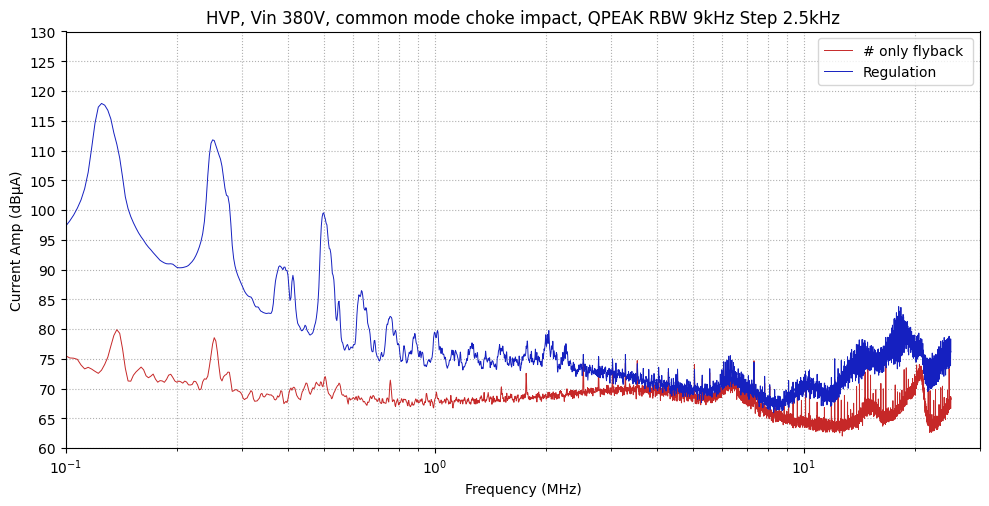

In [71]:
title="HVP, Vin 380V, common mode choke impact, QPEAK RBW 9kHz Step 2.5kHz"
plt.figure(figsize=(10,5))




plt.semilogx(freqs*1e-6, qp, label='# only flyback ', color=rd, linewidth=0.7)  
plt.semilogx(freqs2*1e-6, qp2, label='Regulation', color=bl, linewidth=0.7)  

amax = 130
amin = 60

plt.ylim(amin, amax)
plt.yticks(np.arange(amin, amax+1, 5))
plt.grid(True)

plt.grid(True, which='both', ls=':')
plt.xlabel('Frequency (MHz)')
plt.xlim([0.1, 30])
plt.ylabel('Current Amp (dBµA)')
plt.legend()
plt.tight_layout()
plt.title(title)
plt.show()

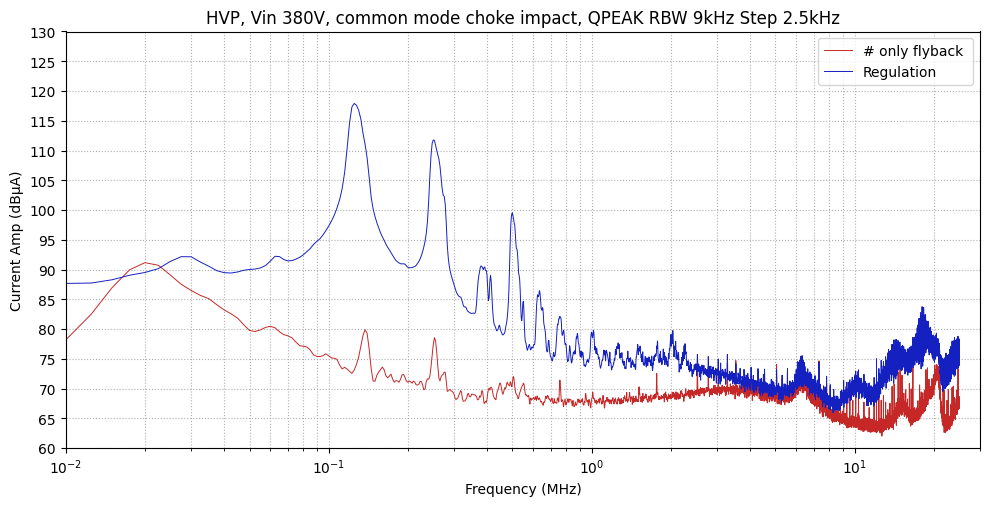

In [72]:
title="HVP, Vin 380V, common mode choke impact, QPEAK RBW 9kHz Step 2.5kHz"
plt.figure(figsize=(10,5))




plt.semilogx(freqs*1e-6, qp, label='# only flyback ', color=rd, linewidth=0.7)  
plt.semilogx(freqs2*1e-6, qp2, label='Regulation', color=bl, linewidth=0.7)  

amax = 130
amin = 60

plt.ylim(amin, amax)
plt.yticks(np.arange(amin, amax+1, 5))
plt.grid(True)

plt.grid(True, which='both', ls=':')
plt.xlabel('Frequency (MHz)')
plt.xlim([0.01, 30])
plt.ylabel('Current Amp (dBµA)')
plt.legend()
plt.tight_layout()
plt.title(title)
plt.show()

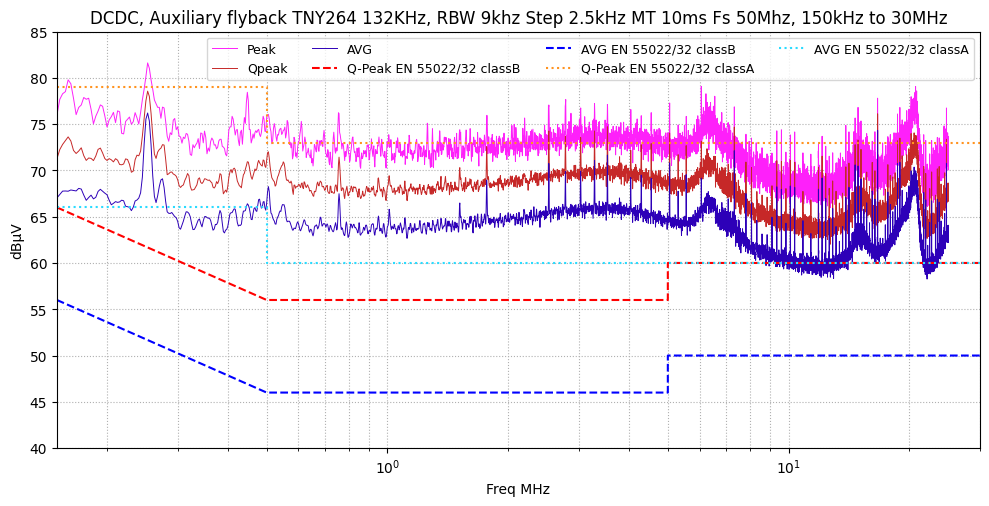

In [83]:
plt.figure(figsize=(10,5))
plt.semilogx(freqs*1e-6, peak, label='Peak', color='#FE20FA', linewidth=0.7)
plt.semilogx(freqs*1e-6, qp, label='Qpeak', color='#C62828', linewidth=0.7) 
plt.semilogx(freqs*1e-6, avg, label='AVG', color='#2D00B8', linewidth=0.7)


# Class A: Limits for industrial/commercial environments → less strict (higher allowed emissions).
# Class B: Limits for residential environments → more strict (lower allowed emissions).
freqs0 = np.array([150e3, 500e3, 5e6, 5e6,30e6])
qp_limits = np.array([66, 56, 56, 60, 60])   # dBµV
avg_limits = np.array([56, 46, 46, 50,50])  # dBµV
plt.semilogx(freqs0*1e-6, qp_limits ,   label='Q-Peak EN 55022/32 classB', c="r",linestyle="--")
plt.semilogx(freqs0*1e-6,avg_limits  ,   label='AVG EN 55022/32 classB', c= "b",linestyle="--")


# CISPR 22 / EN 55032 - CLASS A (Industrial) - Mains Port
# Note: Class A has a step at 500 kHz, not 5 MHz.
freqs0 = np.array([150e3, 500e3, 500e3, 30e6])
qp_limits = np.array([79.0, 79.0, 73.0, 73.0])   # dBµV
avg_limits = np.array([66.0, 66.0, 60.0, 60.0])  # dBµV
plt.semilogx(freqs0*1e-6, qp_limits ,   label='Q-Peak EN 55022/32 classA', c="#FF931F",linestyle=':')
plt.semilogx(freqs0*1e-6,avg_limits  ,   label='AVG EN 55022/32 classA', c= "#29DBFF",linestyle=':')

plt.ylim(40, 85)
plt.yticks(np.arange(40, 85+1, 5))
plt.grid(True)
plt.grid(True, which='both', ls=':')
plt.xlabel('Freq MHz')
plt.xlim([0.15, 30])
plt.ylabel('dBµV')
plt.legend(ncol=4, fontsize=9)
plt.tight_layout()
plt.title("DCDC, Auxiliary flyback TNY264 132KHz, RBW 9khz Step 2.5kHz MT 10ms Fs 50Mhz, 150kHz to 30MHz")
plt.savefig("ExampleOfUse.png")
plt.show()

# Power supp only wire disconnecter

In [43]:
path = "EMI_2026-02-14_09-40-25-204/CH3_raw.npy"
Ts, hvp= path_to_signal(path)

path = "../Test3/EMI_2026-02-12_21-58-40-610/CH3_raw.npy"
path= "EMI_2026-02-14_09-42-40-518/CH3_raw.npy"
Ts, hvp_new = path_to_signal(path)

In [41]:
# AVOID printing result of calculation like 
_="""
--------------------------------------------------
EMI Receiver Configuration:
  RBW           : 9000 Hz
  Step Size     : 2500.00 Hz (Target: 2500 Hz)
  Window Size   : 12493 samples
  FFT Size      : 20000 samples (Zero-Padding: True)
  Detector Time : 0.025 ms
--------------------------------------------------
"""
with contextlib.redirect_stdout(io.StringIO()):
    freqs, peak, avg, qp = receiver(hvp, 1/Ts, rbw=9000, band='B')

with contextlib.redirect_stdout(io.StringIO()):
    freqs2, peak2, avg2, qp2= receiver(hvp_new,1/Ts, rbw=9000, band='B')


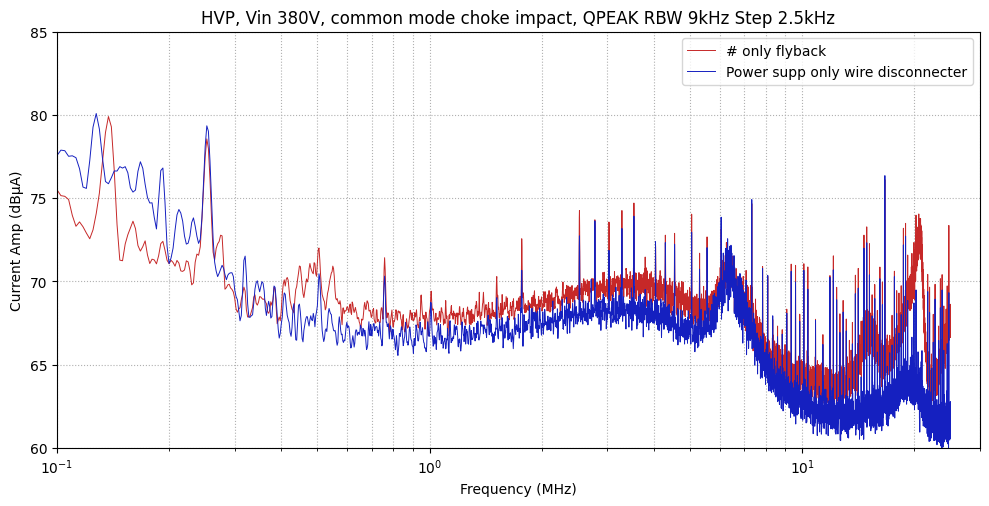

In [44]:
title="HVP, Vin 380V, common mode choke impact, QPEAK RBW 9kHz Step 2.5kHz"
plt.figure(figsize=(10,5))




plt.semilogx(freqs*1e-6, qp, label='# only flyback ', color=rd, linewidth=0.7)  
plt.semilogx(freqs2*1e-6, qp2, label='Power supp only wire disconnecter', color=bl, linewidth=0.7)  

amax = 85
amin = 60

plt.ylim(amin, amax)
plt.yticks(np.arange(amin, amax+1, 5))
plt.grid(True)

plt.grid(True, which='both', ls=':')
plt.xlabel('Frequency (MHz)')
plt.xlim([0.1, 30])
plt.ylabel('Current Amp (dBµA)')
plt.legend()
plt.tight_layout()
plt.title(title)
plt.show()